In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Geometry example (ULA)

import numpy as np

c = 343.0
fs = 16000
f0 = 1000  # 1 kHz
theta = np.deg2rad(30)  # 30 degrees

M = 4
d = 0.04  # 4 cm spacing

mic_positions = np.zeros((M, 3))
mic_positions[:, 0] = np.arange(M) * d  # x-axis


In [17]:
mic_positions

array([[0.  , 0.  , 0.  ],
       [0.04, 0.  , 0.  ],
       [0.08, 0.  , 0.  ],
       [0.12, 0.  , 0.  ]])

In [18]:
def direction_vector(theta):
    u = np.array([np.cos(theta), np.sin(theta), 0])
    return u

u = direction_vector(theta)
print(u)

[0.8660254 0.5       0.       ]


In [4]:
def delays(theta, mic_positions, c=343):
    u = direction_vector(theta)
    return mic_positions @ u / c


In [12]:
delays_calculated = delays(45, mic_positions, c=343)

In [13]:
delays_calculated

array([0.00000000e+00, 6.12620395e-05, 1.22524079e-04, 1.83786119e-04,
       2.45048158e-04, 3.06310198e-04, 3.67572237e-04, 4.28834277e-04])

In [22]:
# tau = mic_positions @ u / c
# [0.         0.03464102 0.06928203 0.10392305]
tau = np.dot(mic_positions, u) / c
print(tau)

[0.         0.00010099 0.00020199 0.00030298]


In [23]:
# Create test signals

T = 0.01  # 10 ms
N = int(T * fs)
t = np.arange(N) / fs

s = np.sin(2*np.pi*f0*t)

signals = np.zeros((M, N))
for m in range(M):
    signals[m] = np.sin(2*np.pi*f0*(t - tau[m]))


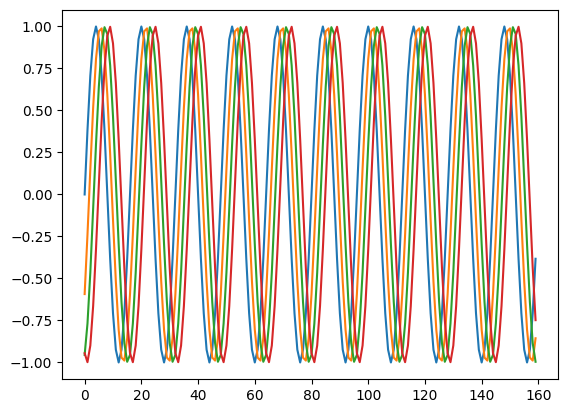

In [30]:
for i in range(signals.shape[0]):
    plt.plot(signals[i,:])

In [35]:
# 3- Delay-and-Sum Beamformer (Wideband, time-domain)

# undo the propagation delays: applying +τₘ shifts > phase aligned signals


def delay_and_sum(signals, delays, fs):
    """
    signals: shape (M, N)
    delays: seconds, shape (M,)
    """
    M, N = signals.shape
    y = np.zeros(N)
    
    for m in range(M):
        shift = int(np.round(tau[m] * fs))
        y += np.roll(signals[m], -shift)
        
    return y / M


In [32]:
y = delay_and_sum(signals, tau, fs)

signals[m] = delayed versions of sine

y = reconstructed coherent sine

SNR improves

Phase aligns

Interference from other directions would decorrelate

In [38]:
# 4) Frequency-domain beamforming (proper wideband)

# def steering_vector(freq, theta, mic_positions, c=343):
#     omega = 2*np.pi*freq
#     tau = delays(theta, mic_positions, c)
#     return np.exp(-1j * omega * tau)

def steering_vector(freq, tau):
    omega = 2*np.pi*freq
    return np.exp(-1j * omega * tau)


In [39]:
freq = 1000  # 1 kHz
a = steering_vector(freq, tau)


In [41]:
# Apply frequency-domain beamforming

def ds_beamform_freq(Xf, a):
    w = a / len(a)           # DS weights
    return np.conj(w) @ Xf   # beamformed output


In [42]:
# Concrete Python MVDR (real usage)

def spatial_covariance(X):
    return (X @ X.conj().T) / X.shape[1]


In [43]:
def mvdr_weights(R, a):
    R_inv = np.linalg.pinv(R)
    num = R_inv @ a
    den = a.conj().T @ R_inv @ a
    return num / den


In [44]:
# Example usage at one frequency bin:
R = spatial_covariance(Xf)   # Xf shape: (M, T)
a = steering_vector(freq, tau)
w_mvdr = mvdr_weights(R, a)
Y = np.conj(w_mvdr) @ Xf


NameError: name 'Xf' is not defined

In [7]:
def ds_weights(freq, theta, mic_positions):
    a = steering_vector(freq, theta, mic_positions)
    return a / len(a)


In [8]:
# 5) MVDR (Capon) Beamformer 🔥 (signal enhancement core)

def mvdr_weights(R, a):
    R_inv = np.linalg.pinv(R)
    num = R_inv @ a
    den = a.conj().T @ R_inv @ a
    return num / den


In [9]:
# 6) Spatial covariance estimation

def spatial_covariance(X):
    # X: shape (M, T) for one frequency bin
    return (X @ X.conj().T) / X.shape[1]


In [10]:
# 7) DOA Estimation (MUSIC)

def music_spectrum(R, mic_positions, thetas, freq, num_sources=1):
    eigvals, eigvecs = np.linalg.eigh(R)
    idx = np.argsort(eigvals)[::-1]
    En = eigvecs[:, idx[num_sources:]]  # noise subspace
    
    P = []
    for th in thetas:
        a = steering_vector(freq, th, mic_positions)
        denom = a.conj().T @ En @ En.conj().T @ a
        P.append(1 / np.abs(denom))
    return np.array(P)


In [11]:
mic_positions

array([[0.  , 0.  , 0.  ],
       [0.04, 0.  , 0.  ],
       [0.08, 0.  , 0.  ],
       [0.12, 0.  , 0.  ],
       [0.16, 0.  , 0.  ],
       [0.2 , 0.  , 0.  ],
       [0.24, 0.  , 0.  ],
       [0.28, 0.  , 0.  ]])